# 0.0. IMPORTS

In [268]:
import numpy as np
import pandas as pd
import inflection
import math
import seaborn as sns
import datetime

from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from matplotlib import pyplot as plt
from scipy import stats as ss
import matplotlib.gridspec as gridspec

## 0.1 Help Functions

In [214]:
def cramer_v(x,y):
    cm = pd.crosstab(x,y).values
    n = cm.sum()
    r, k = cm.shape

    chi2 = ss.chi2_contingency(cm)[0]
    chi2corr = max(0, chi2 - (k-1)*(r-1)/(n-1))
    kcorr = k-(k-1)**2/(n-1)
    rcorr = r-(r-1)**2/(n-1)

    return np.sqrt((chi2corr/n)/(min(kcorr-1,rcorr-1)))

## 0.2 Load Data

In [215]:
df_sales_raw = pd.read_csv('../dataset/train.csv', low_memory=False)
df_store_raw = pd.read_csv('../dataset/store.csv', low_memory=False)

df_raw = pd.merge( df_sales_raw, df_store_raw, how='left', on='Store')

In [216]:
df_raw.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


# 1.0. DESCRIÇÃO DOS DADOS


In [217]:
df1 = df_raw.copy()
df1.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

## 1.1. Rename Columns

In [218]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval']

snakecase = lambda x: inflection.underscore( x )

cols_new = list(map(snakecase,cols_old))

#rename
df1.columns = cols_new

df1.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval'],
      dtype='object')

## 1.2. Data Dimensions

In [219]:
print(f'Number of rows: {df1.shape[0]}')
print(f'Number of columns: {df1.shape[1]}')

Number of rows: 1017209
Number of columns: 18


## 1.3. Data Types

In [220]:
df1['date'] = pd.to_datetime(df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
dtype: object

## 1.4 Check NA


In [221]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## 1.5 Fillout NA


In [222]:
#competition_distance              2642
df1['competition_distance'] = df1['competition_distance'].apply(lambda x: 200000.0 if math.isnan(x) else x)

#competition_open_since_month    323348
df1['competition_open_since_month'] = df1.apply(lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis = 1)

#competition_open_since_year     323348
df1['competition_open_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis = 1)

#promo2_since_week               508031
df1['promo2_since_week'] = df1.apply(lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis = 1)

#promo2_since_year               508031
df1['promo2_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis = 1)

#promo_interval                  508031
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

df1['promo_interval'].fillna(0, inplace=True)

df1['month_map'] = df1['date'].dt.month.map(month_map)

df1['is_promno'] = df1[['promo_interval','month_map']].apply(lambda x: 0 if x['promo_interval'] == 0 else 1 if x['month_map'] in x['promo_interval'].split(',') else 0, axis=1 )

/tmp/ipykernel_2499/785796234.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['promo_interval'].fillna(0, inplace=True)


## 1.6 Change Types

In [223]:
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype(int)
df1['promo2_since_week'] = df1['promo2_since_week'].astype(int)
df1['promo2_since_year'] = df1['promo2_since_year'].astype(int)
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                          object
month_map                               object
is_promno                                int64
dtype: object

## 1.7 Descriptive Statistical

In [224]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

### 1.7.1 Numerical Attributes

In [225]:
# Central Tendency = mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion = std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenate

m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes','min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']

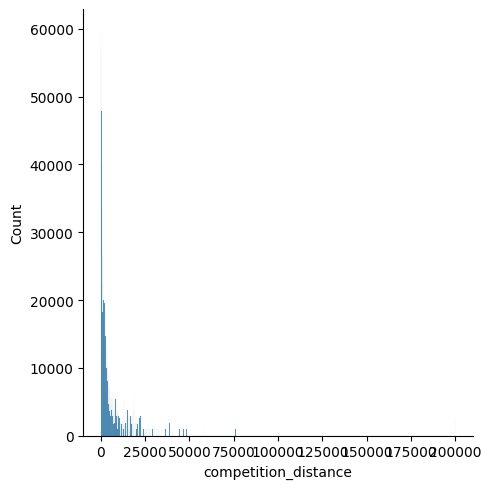

In [226]:
sns.displot(df1['competition_distance'])

### 1.7.2 Categorical attributes

In [227]:
cat_attributes.apply(lambda x: x.unique().shape[0])

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

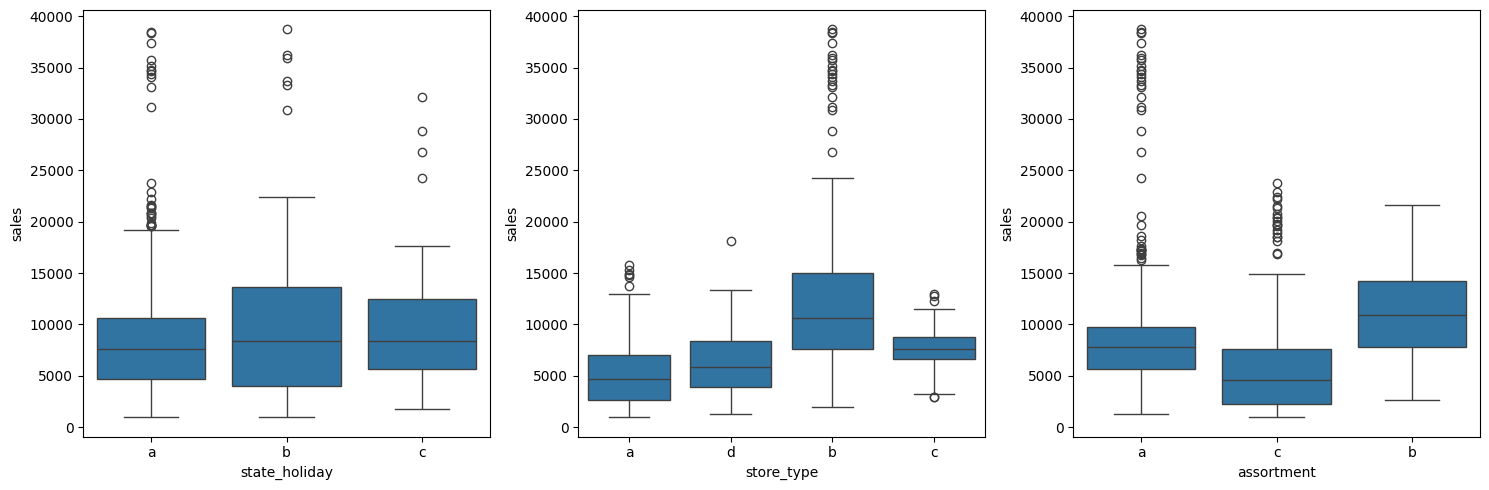

In [228]:
aux1 = df1[(df1['state_holiday'] != '0') & (df1['sales']>0)]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='state_holiday',y='sales',data=aux1)

plt.subplot(1, 3, 2)
sns.boxplot(x='store_type',y='sales',data=aux1)

plt.subplot(1, 3, 3)
sns.boxplot(x='assortment',y='sales',data=aux1)

plt.tight_layout()  # Ajusta os espaços entre os gráficos
plt.show()



# 2.0 FEATURES ENGINEERING

In [ ]:
df2 = df1.copy()

4

## 2.1 Criação de Hipoteses

### 2.1.1 Hipoteses de loja

In [230]:
# 1. Lojas com numero maior de funcionarios deveriam vender mais.
# 
# 2. Lojas com maior capacidade de estoque deveriam vender mais 
# 
# 3. Lojas com maior porte deveriam vender mais
#
# 4. Lojas com maior sortimento deveriam vender mais
#
# 5. Lojas com competidores mais proximos deveriam vender menos
#
# 6. Lojas com competidores a mais tempo deveriam vender mais 

### 2.1.2 Hipoteses de produto


In [231]:
# 1. Lojas que investem mais em marketing deveriam vender mais.
# 
# 2. Lojas com maior exposição de produtos deveriam vender mais
# 
# 3. Lojas com produtos com preços menores deveriam vender mais
#
# 4. Lojas com promoções mais agressivas (descontos maiores), deveriam vender mais
#
# 5. Lojas com promoções ativas por mais tempo deveriam vender mais
#
# 6. Lojas com mais dias de promoção deveriam vender mais
#
# 7. Lojas com mais promoções consecutivas deveriam vender mais

### 2.1.3 Hipoteses Temporais

In [232]:
# 1. Lojas abertas durante o feriado de Natal deveriam vender mais.
# 
# 2. Lojas deveriam vender mais ao longo dos anos
# 
# 3. Lojas deveriam vender mais no segundo semestre do ano
#
# 4. Lojas deveriam vender mais depois do dia 10 de cada mes
# 
# 5. Lojas deveriam vender menos aos finais de semana
# 
# 6. Lojas deveriam vender menos durante os feriados escolares.  

## 2.2 Lista final de hipoteses

In [233]:
# 1. Lojas com maior sortimento deveriam vender mais
# 2. Lojas com competidores mais proximos deveriam vender menos
# 3. Lojas com competidores a mais tempo deveriam vender mais 



In [234]:
# 4. Lojas com promoções ativas por mais tempo deveriam vender mais
# 5. Lojas com mais dias de promoção deveriam vender mais
# 6. Lojas com mais promoções consecutivas deveriam vender mais



In [235]:
# 7. Lojas abertas durante o feriado de Natal deveriam vender mais.
# 8. Lojas deveriam vender mais ao longo dos anos
# 9. Lojas deveriam vender mais no segundo semestre do ano
# 10. Lojas deveriam vender mais depois do dia 10 de cada mes
# 11. Lojas deveriam vender menos aos finais de semana
# 12. Lojas deveriam vender menos durante os feriados escolares.  

## 2.3 Feature Engineering

In [236]:
#year
df2['year'] = df2['date'].dt.year

#month
df2['month'] = df2['date'].dt.month

#day
df2['day'] = df2['date'].dt.day

#Week
df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

#week of year
df2['week_of_year'] = df2['date'].dt.isocalendar().week
df2['week_of_year'].astype(int)

#competition since
df2['competition_since'] = df2.apply(lambda x: datetime.datetime(year=x['competition_open_since_year'], month=x['competition_open_since_month'], day=1), axis=1)
df2['competition_time_month']=((df2['date'] - df2['competition_since'])/30).apply(lambda x: x.days).astype(int)

#promo since
df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)
df2['promo_since'] = df2['promo_since'].apply(lambda x: datetime.datetime.strptime(x + '-1', '%Y-%W-%w') - datetime.timedelta(days=7))

df2['promo_time_week'] = ((df2['date'] - df2['promo_since'])/7).apply(lambda x: x.days).astype(int)

#assortment
df2['assortment'] = df2['assortment'].apply(lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended')

#state_holiday
df2['state_holiday'] = df2['state_holiday'].apply(lambda x: 'public_holiday' if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day')

# 3.0 FILTRAGEM DE VARIAVEIS

In [238]:
df3=df2.copy()

4

## 3.1 Filtragem das Linhas

In [239]:
df3 = df3[(df3['open'] != 0) & (df3['sales'] > 0)]

## 3.2 Seleção das Colunas

In [240]:
cols_drop = ['customers','open','promo_interval','month_map']

df3 = df3.drop(cols_drop,axis=1)

# 4.0 EDA ( EXPLORATION DATA ANALYSIS)

In [241]:
df4 = df3.copy()

4

## 4.1 Analise Univariada

### 4.1.1 Response Variable

/tmp/ipykernel_2499/2099491854.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df4['sales'],kde=False)


<Axes: xlabel='sales'>

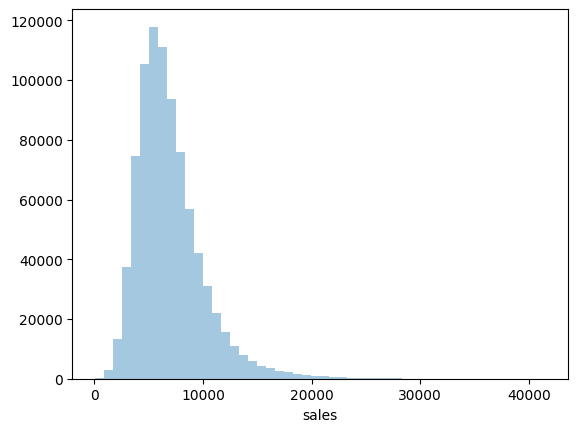

In [242]:
sns.distplot(df4['sales'],kde=False)

### 4.1.2 Numerical Variable

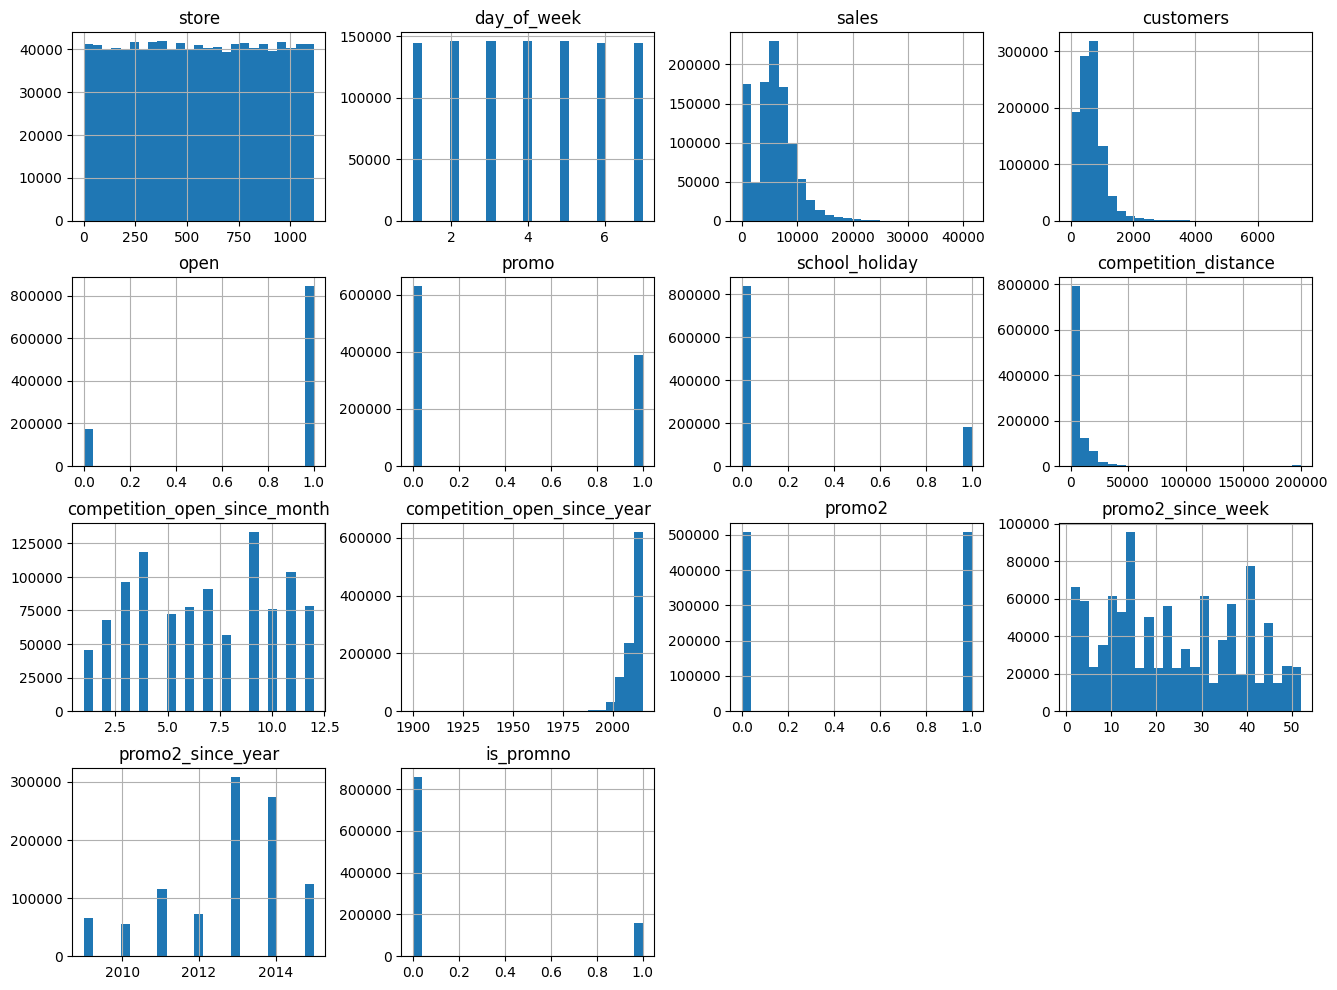

In [243]:
num_attributes.hist(figsize=(16, 12), bins=25);

### 4.1.3 Categorical Variable

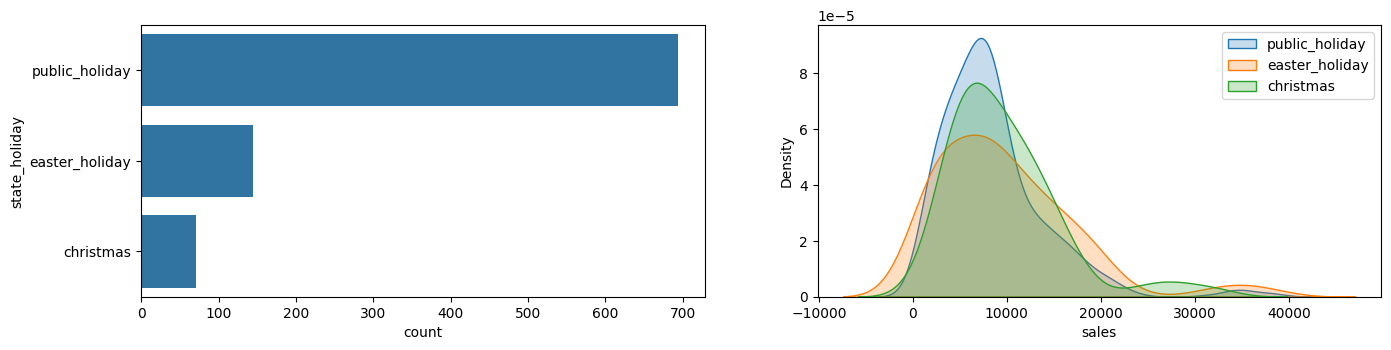

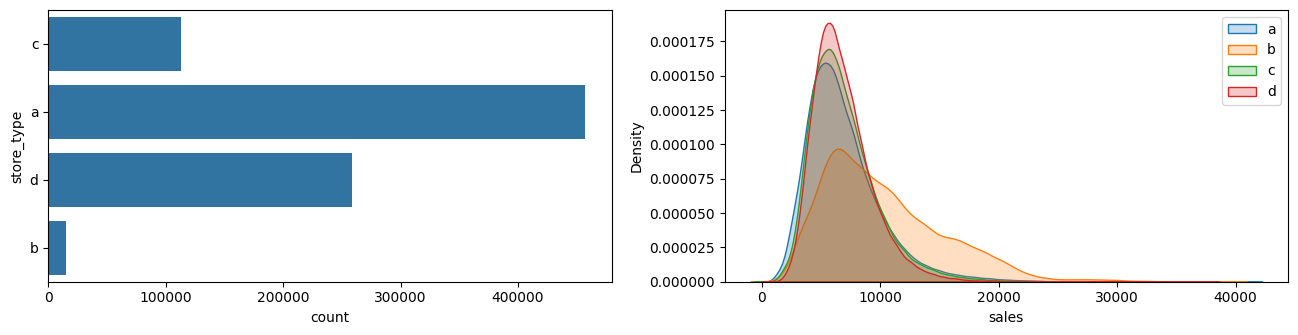

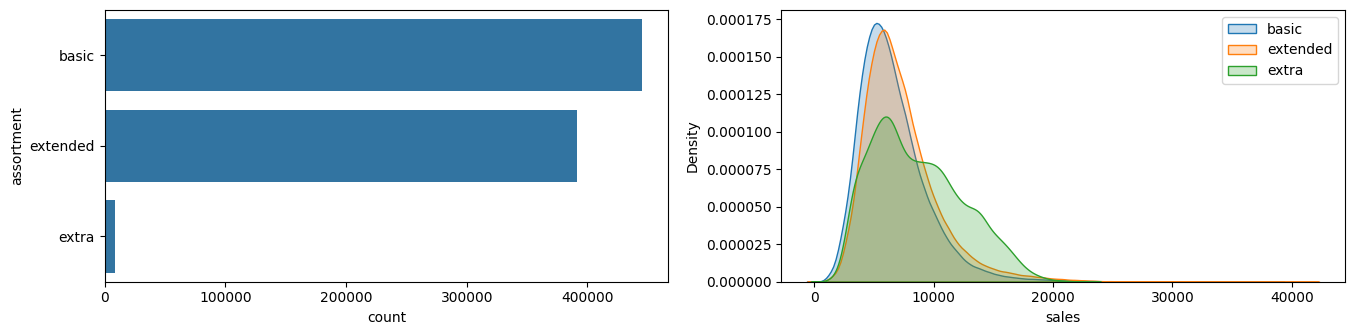

In [244]:
#state_holiday

plt.figure(figsize= (16,12))
plt.subplot(3,2,1)
a = df4[df4['state_holiday'] != 'regular_day']
sns.countplot(a['state_holiday'])

plt.subplot(3,2,2)
sns.kdeplot(df4[df4['state_holiday'] == 'public_holiday']['sales'], label = 'public_holiday', fill = True)
sns.kdeplot(df4[df4['state_holiday'] == 'easter_holiday']['sales'], label = 'easter_holiday', fill = True)
sns.kdeplot(df4[df4['state_holiday'] == 'christmas']['sales'], label = 'christmas', fill = True)
plt.legend();

#store_type - a, b, c, d
plt.figure(figsize= (16,12))

plt.subplot(3,2,3)
sns.countplot(df4['store_type'])

plt.subplot(3,2,4)
sns.kdeplot(df4[df4['store_type'] == 'a']['sales'], label = 'a', fill = True)
sns.kdeplot(df4[df4['store_type'] == 'b']['sales'], label = 'b', fill = True)
sns.kdeplot(df4[df4['store_type'] == 'c']['sales'], label = 'c', fill = True)
sns.kdeplot(df4[df4['store_type'] == 'd']['sales'], label = 'd', fill = True)
plt.legend();

#assortment - basic, extended, extra 
plt.figure(figsize= (16,12))

plt.subplot(3,2,5)
sns.countplot(df4['assortment'])

plt.subplot(3,2,6)
sns.kdeplot(df4[df4['assortment'] == 'basic']['sales'], label = 'basic', fill = True)
sns.kdeplot(df4[df4['assortment'] == 'extended']['sales'], label = 'extended', fill = True)
sns.kdeplot(df4[df4['assortment'] == 'extra']['sales'], label = 'extra', fill = True)
plt.legend();

## 4.2 Analise Bivariada

### 4.2.1 H1 - Lojas com maior sortimento deveriam vender mais
### **Falsa - Lojas com maior sortimento vendem menos**

<Axes: xlabel='year_week'>

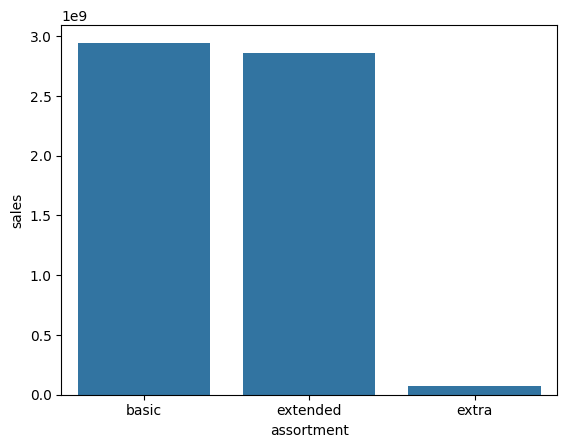

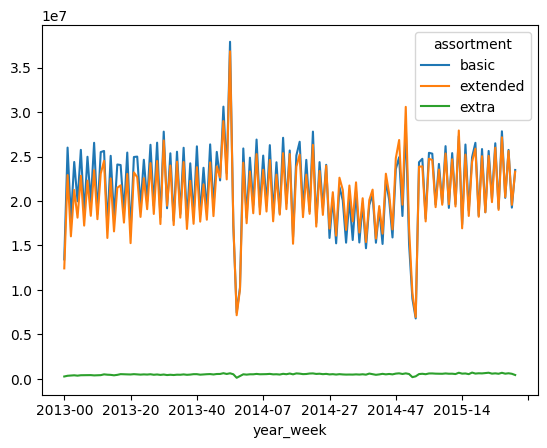

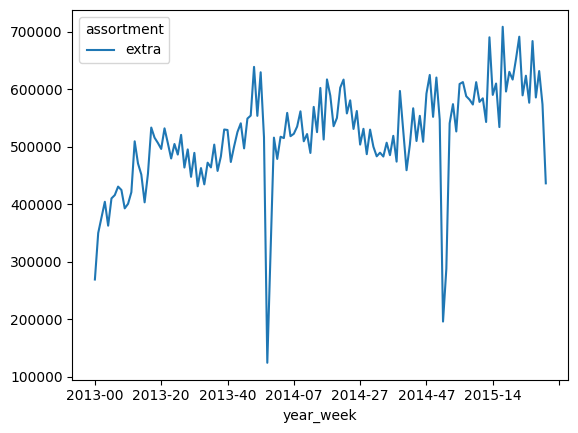

In [245]:
aux1 = df4[['assortment','sales']].groupby('assortment').sum().reset_index()
sns.barplot(x = 'assortment', y = 'sales', data = aux1);

aux2 = df4[['year_week','assortment','sales']].groupby(['year_week','assortment']).sum().reset_index()
aux2.pivot(index = 'year_week', columns='assortment', values = 'sales').plot()

aux3=aux2[aux2['assortment'] == 'extra']
aux3.pivot(index = 'year_week', columns='assortment', values = 'sales').plot()

### 4.2.2 H2 - Lojas com competidores mais proximos deveriam vender menos
### **Falsa - Lojas com competidores mais proximos vendem mais**

/tmp/ipykernel_2499/1556792290.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aux2 = aux2[['competition_distance_binned','sales']].groupby('competition_distance_binned').sum().reset_index()


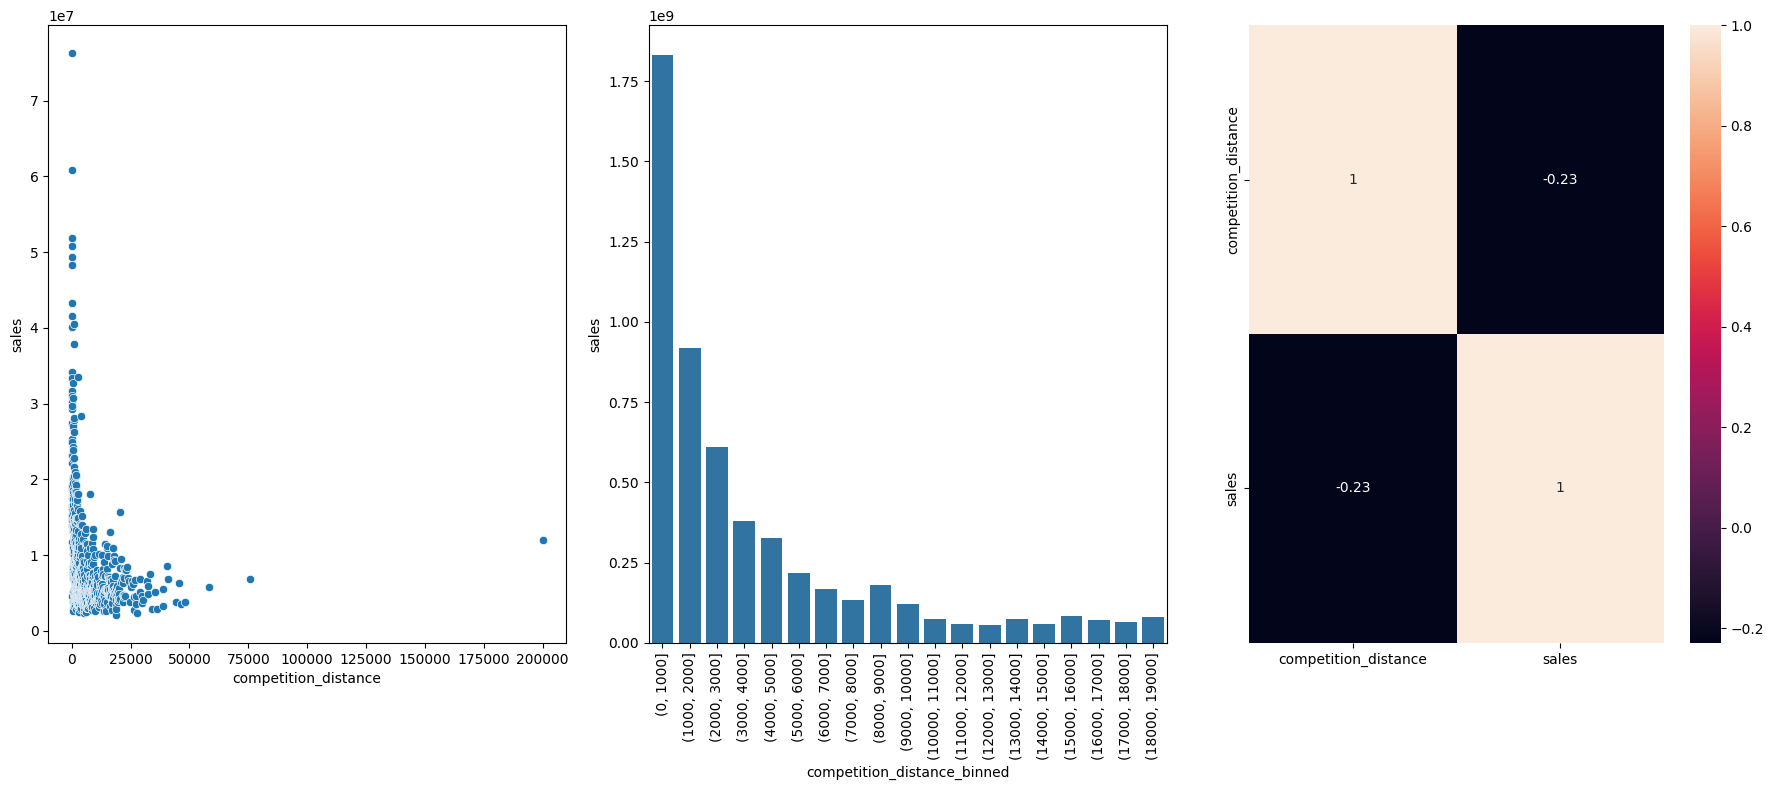

In [246]:
aux1 = df4[['competition_distance','sales']].groupby('competition_distance').sum().reset_index()

plt.figure(figsize=(18, 8))
plt.subplot(1,3,1)
sns.scatterplot(x='competition_distance', y='sales',data=aux1)


plt.subplot(1,3,2)
bins=list(np.arange(0,20000,1000))
aux2 = aux1.copy()
aux2['competition_distance_binned'] = pd.cut(aux2['competition_distance'],bins=bins)
aux2 = aux2[['competition_distance_binned','sales']].groupby('competition_distance_binned').sum().reset_index()
sns.barplot(x='competition_distance_binned',y='sales',data=aux2)
plt.xticks(rotation=90)

plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'), annot=True)

plt.tight_layout()  # Ajusta os espaçamentos entre os subplots
plt.show()


### 4.2.3 H3 - Lojas com competidores a mais tempo deveriam vender mais 
### **Falsa - Lojas com competidores a mais tempo vendem menos**

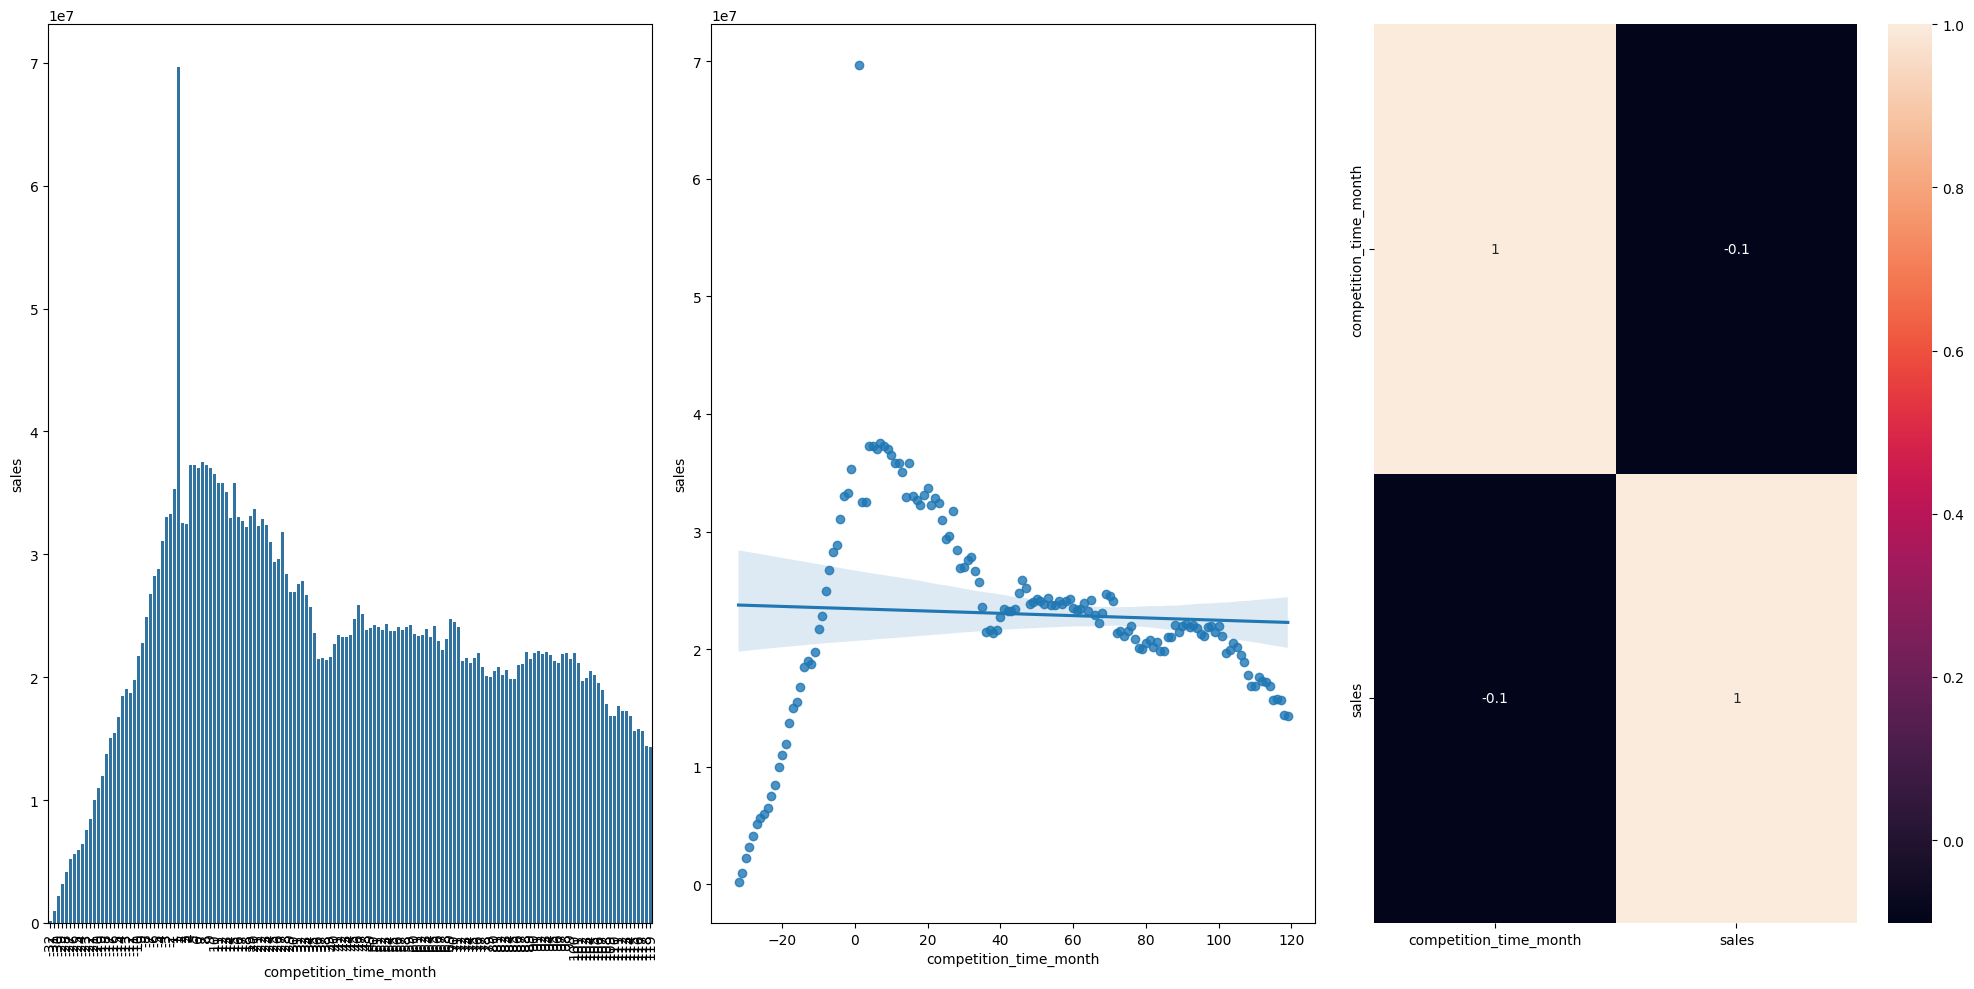

In [247]:
plt.figure(figsize=(20,10))
plt.subplot(1,3,1)

aux1 = df4[['competition_time_month','sales']].groupby('competition_time_month').sum().reset_index()
aux2=aux1[(aux1['competition_time_month'] < 120) & (aux1['competition_time_month'] != 0)]

sns.barplot(x='competition_time_month',y='sales', data=aux2)
plt.xticks(rotation=90);


plt.subplot(1,3,2)
sns.regplot(x='competition_time_month',y='sales', data=aux2)

plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'), annot=True)

plt.tight_layout()  # Ajusta os espaçamentos entre os subplots
plt.show()

### 4.2.4 H4 - Lojas com promoções ativas por mais tempo deveriam vender mais
### **Falsa - As lojas vendem mais até um determinado periodo de promoção ativa, após esse periodo, as vendas caem**

In [248]:
df4.head()

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,...,is_promno,year,month,day,year_week,week_of_year,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,1,regular_day,1,c,basic,1270.0,...,0,2015,7,31,2015-30,31,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,1,regular_day,1,a,basic,570.0,...,1,2015,7,31,2015-30,31,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,1,regular_day,1,a,basic,14130.0,...,1,2015,7,31,2015-30,31,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1,regular_day,1,c,extended,620.0,...,0,2015,7,31,2015-30,31,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,1,regular_day,1,a,basic,29910.0,...,0,2015,7,31,2015-30,31,2015-04-01,4,2015-07-27,0


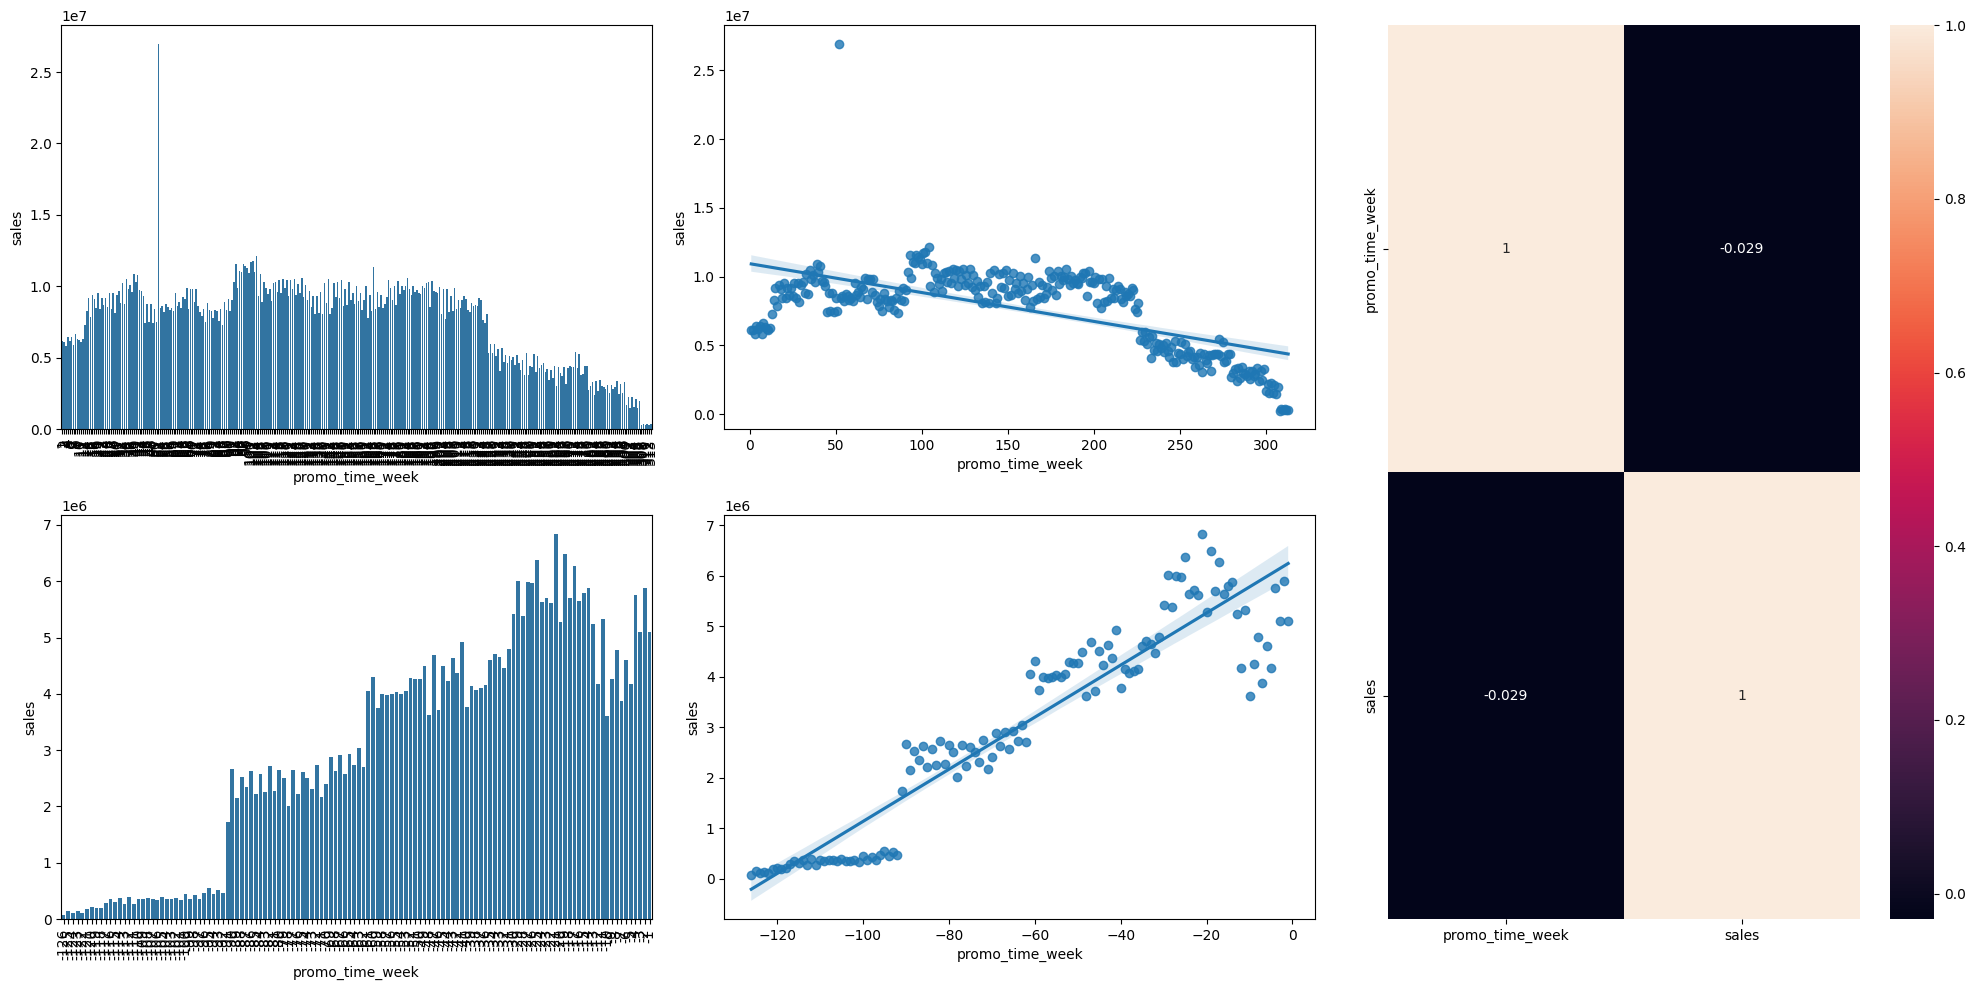

In [249]:
aux1 = df4[['promo_time_week', 'sales']].groupby('promo_time_week').sum().reset_index()

grid = gridspec.GridSpec(2,3)

plt.figure(figsize=(20,10))

plt.subplot(grid[0,0])
aux2 = aux1[aux1['promo_time_week'] > 0]
sns.barplot(x='promo_time_week', y='sales', data=aux2 ); 
plt.xticks(rotation = 90)

plt.subplot(grid[0,1])
sns.regplot(x='promo_time_week', y='sales', data=aux2 )

plt.subplot(grid[1,0])
aux3 = aux1[aux1['promo_time_week'] < 0]
sns.barplot(x='promo_time_week', y='sales', data=aux3 ); 
plt.xticks(rotation = 90)

plt.subplot(grid[1,1])
sns.regplot(x='promo_time_week', y='sales', data=aux3 )

plt.subplot(grid[:,2])
sns.heatmap(aux1.corr(method='pearson'), annot=True);

plt.tight_layout()  # Ajusta os espaçamentos entre os subplots
plt.show()

### <s>4.2.5 H5 - Lojas com mais dias de promoção deveriam vender mais</s>

### 4.2.6 H6 - Lojas com mais promoções consecutivas deveriam vender mais
### **Falsa -   Lojas com mais promoções consecutivas vendem menos**

In [250]:

df4[['promo','promo2','sales']].groupby(['promo', 'promo2']).sum().reset_index()

,promo,promo2,sales
0,0,0,1482612096
1,0,1,1289362241
2,1,0,1628930532
3,1,1,1472275754


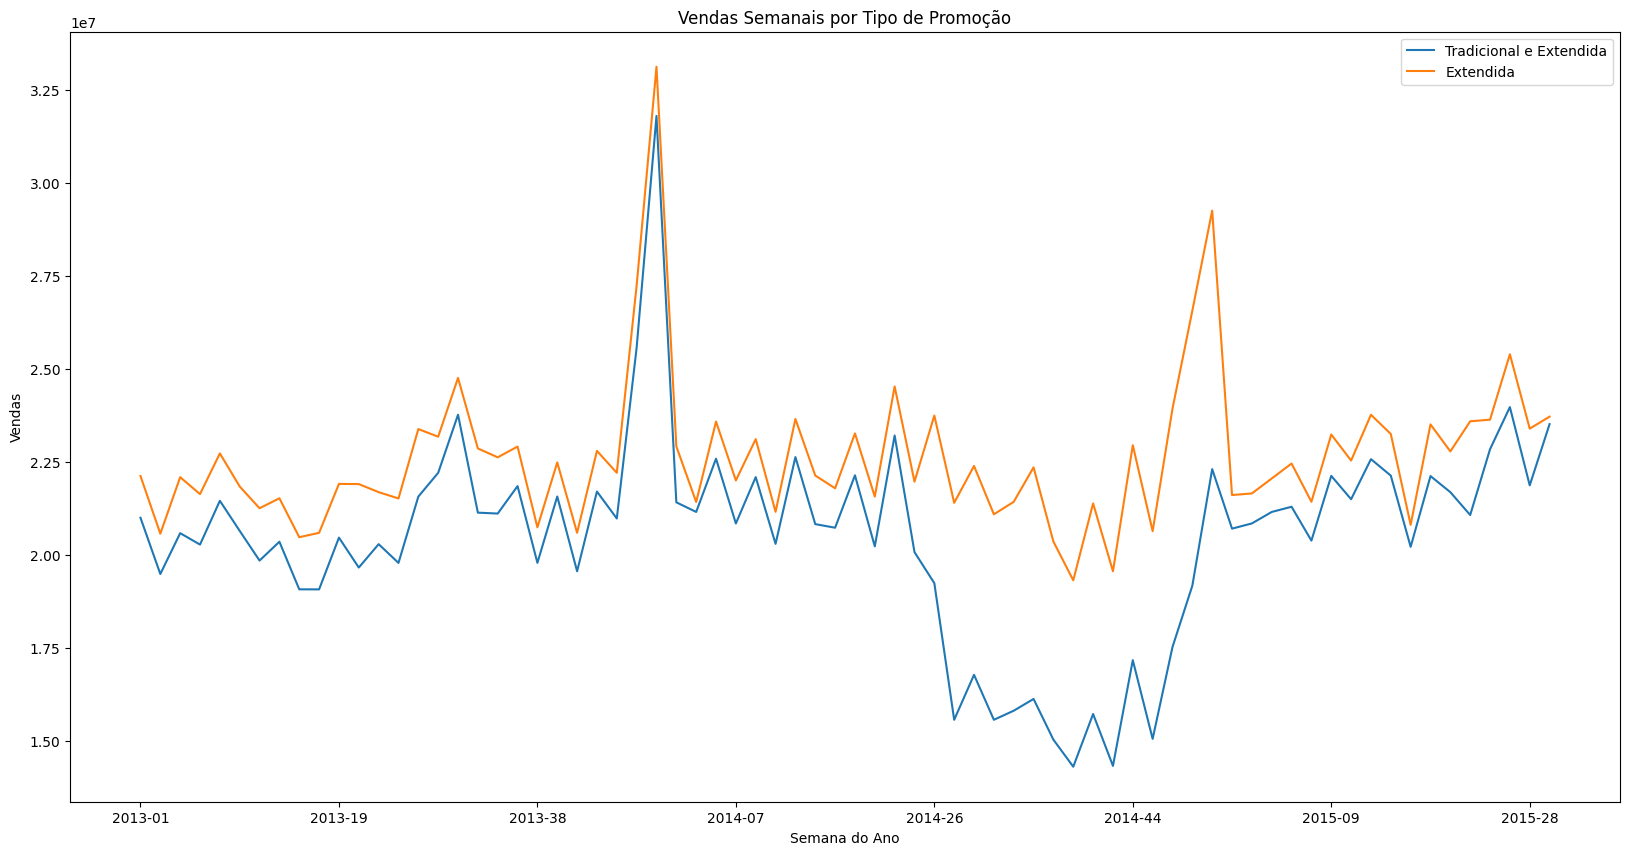

In [251]:
plt.figure(figsize=(20, 10))

aux1 = df4[(df4['promo'] == 1) & (df4['promo2'] == 1 )][['year_week', 'sales']].groupby('year_week').sum().reset_index()
aux2 = df4[(df4['promo'] == 1) & (df4['promo2'] == 0 )][['year_week', 'sales']].groupby('year_week').sum().reset_index()


ax = aux1.plot(x='year_week', y='sales', ax=plt.gca(), label="Tradicional e Extendida")  
aux2.plot(x='year_week', y='sales', ax=ax, label="Extendida")

# Adicionar legenda e título
ax.set_title("Vendas Semanais por Tipo de Promoção")
ax.set_xlabel("Semana do Ano")
ax.set_ylabel("Vendas")
ax.legend()

# Mostrar o gráfico
plt.show()

### 4.2.7 H7 - Lojas abertas durante o feriado de Natal deveriam vender mais.
### **Falsa - O feriado do Natal é o que menos vende no ano**

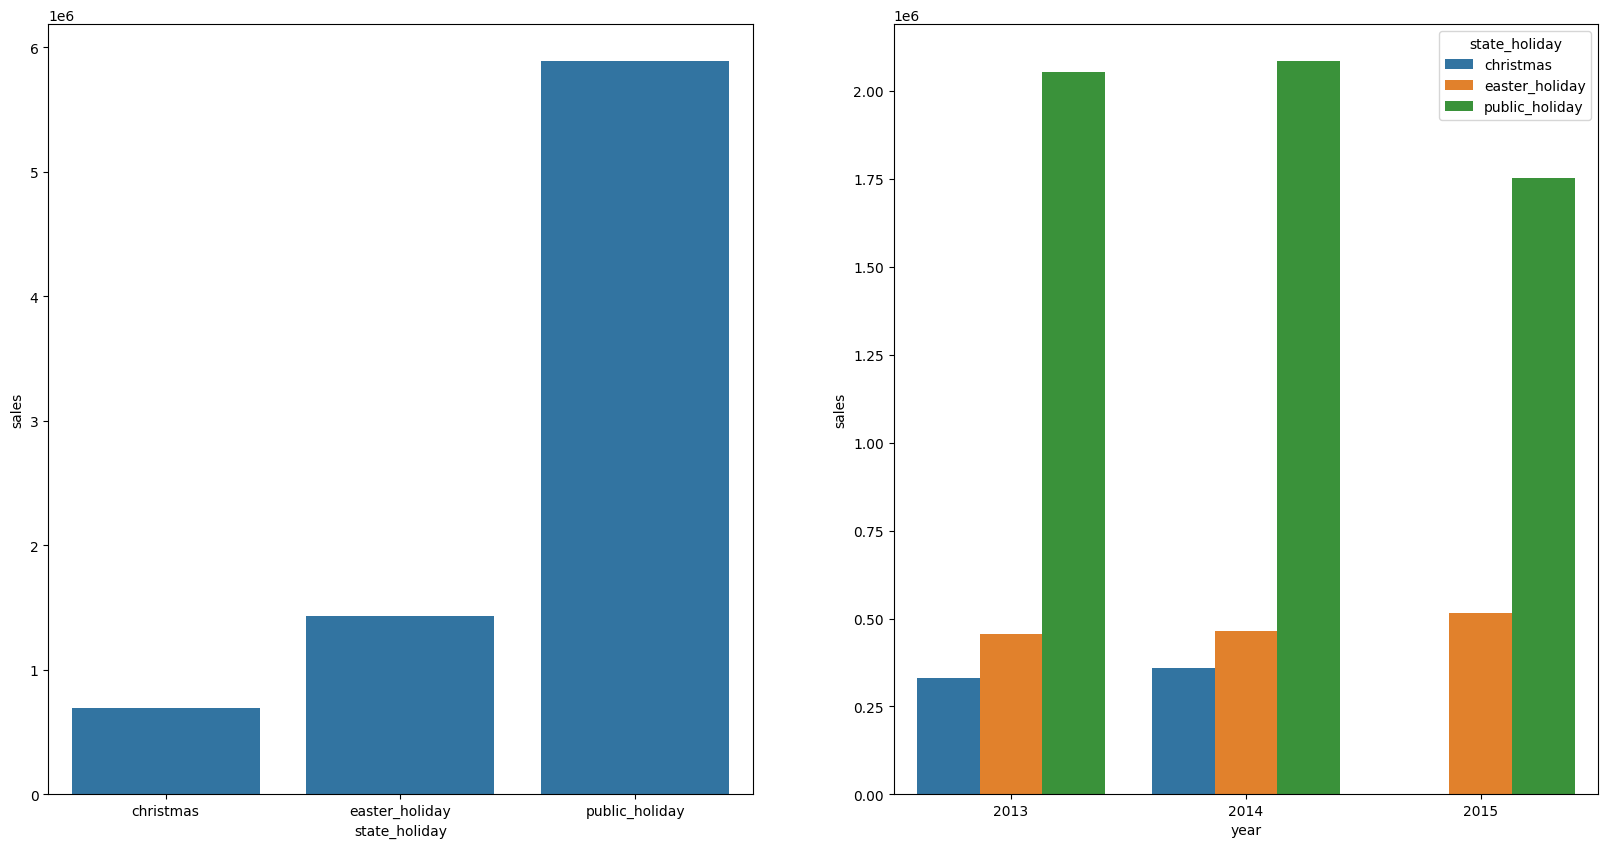

In [252]:
aux = df4[df4['state_holiday'] != 'regular_day']

plt.figure(figsize=(20, 10))

plt.subplot(1,2,1)
aux1 = aux[['state_holiday','sales']].groupby('state_holiday').sum().reset_index()
sns.barplot(x='state_holiday', y = 'sales', data = aux1);

plt.subplot(1,2,2)
aux2 = aux[['year','state_holiday','sales']].groupby(['year', 'state_holiday']).sum().reset_index()
sns.barplot(x='year',y='sales',hue='state_holiday',data=aux2)

plt.show()

### 4.2.8 H8 - Lojas deveriam vender mais ao longo dos anos
### **Falsa - Lojas vendem menos ao longo dos anos**

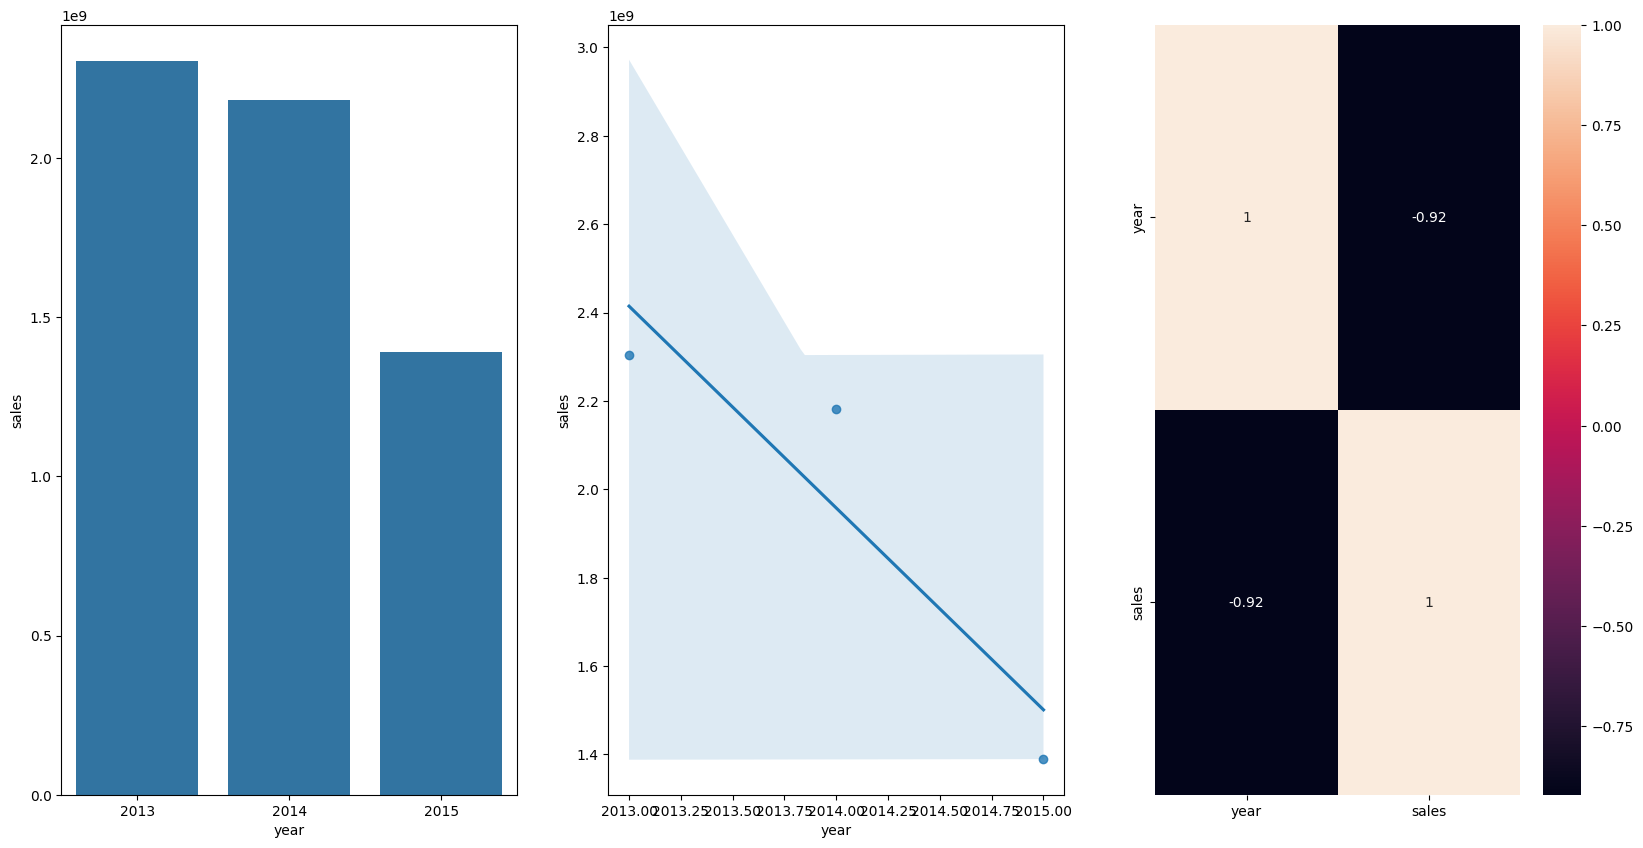

In [253]:
aux1 = df4[['year', 'sales']].groupby('year').sum().reset_index()

plt.figure(figsize=(20, 10))

plt.subplot(1,3,1)
sns.barplot(x='year', y='sales', data=aux1);
plt.subplot(1,3,2)
sns.regplot(x='year', y='sales', data=aux1);
plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'),annot = True);
plt.show()

### 4.2.9 H9 - Lojas deveriam vender mais no segundo semestre do ano
### **Falsa - As lojas vendem menos no segundo semestre do ano**


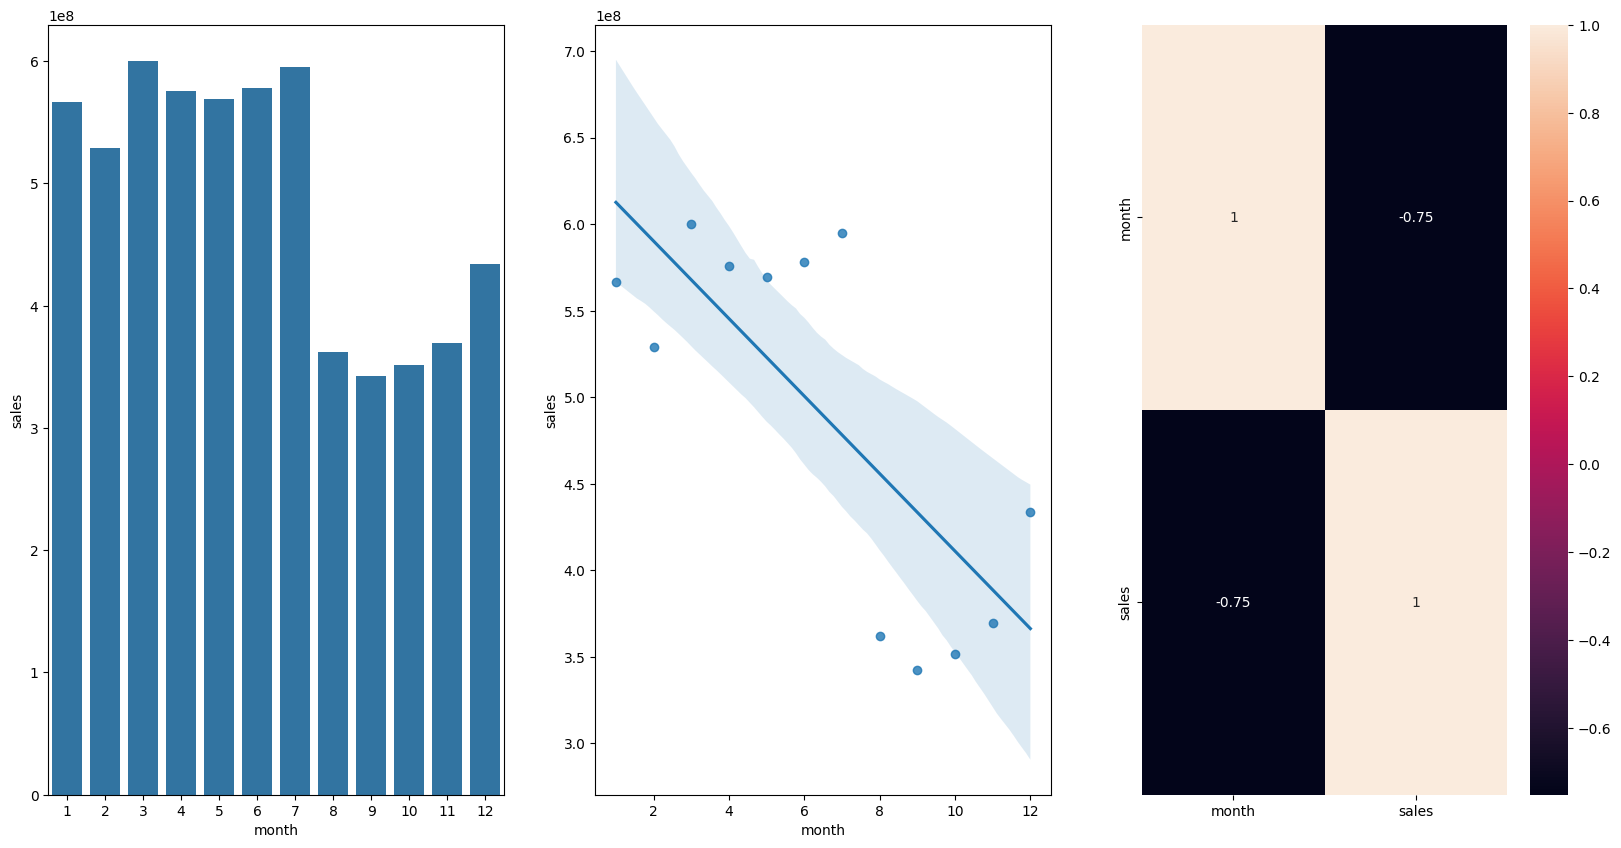

In [254]:
aux1 = df4[['month', 'sales']].groupby('month').sum().reset_index()

plt.figure(figsize=(20, 10))

plt.subplot(1,3,1)
sns.barplot(x='month', y='sales', data=aux1);
plt.subplot(1,3,2)
sns.regplot(x='month', y='sales', data=aux1);
plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'),annot = True);
plt.show()

### 4.2.10 H10 - Lojas deveriam vender mais depois do dia 10 de cada mes
### **Verdadeira - Lojas vendem mais depois do dia 10 de cada mes**


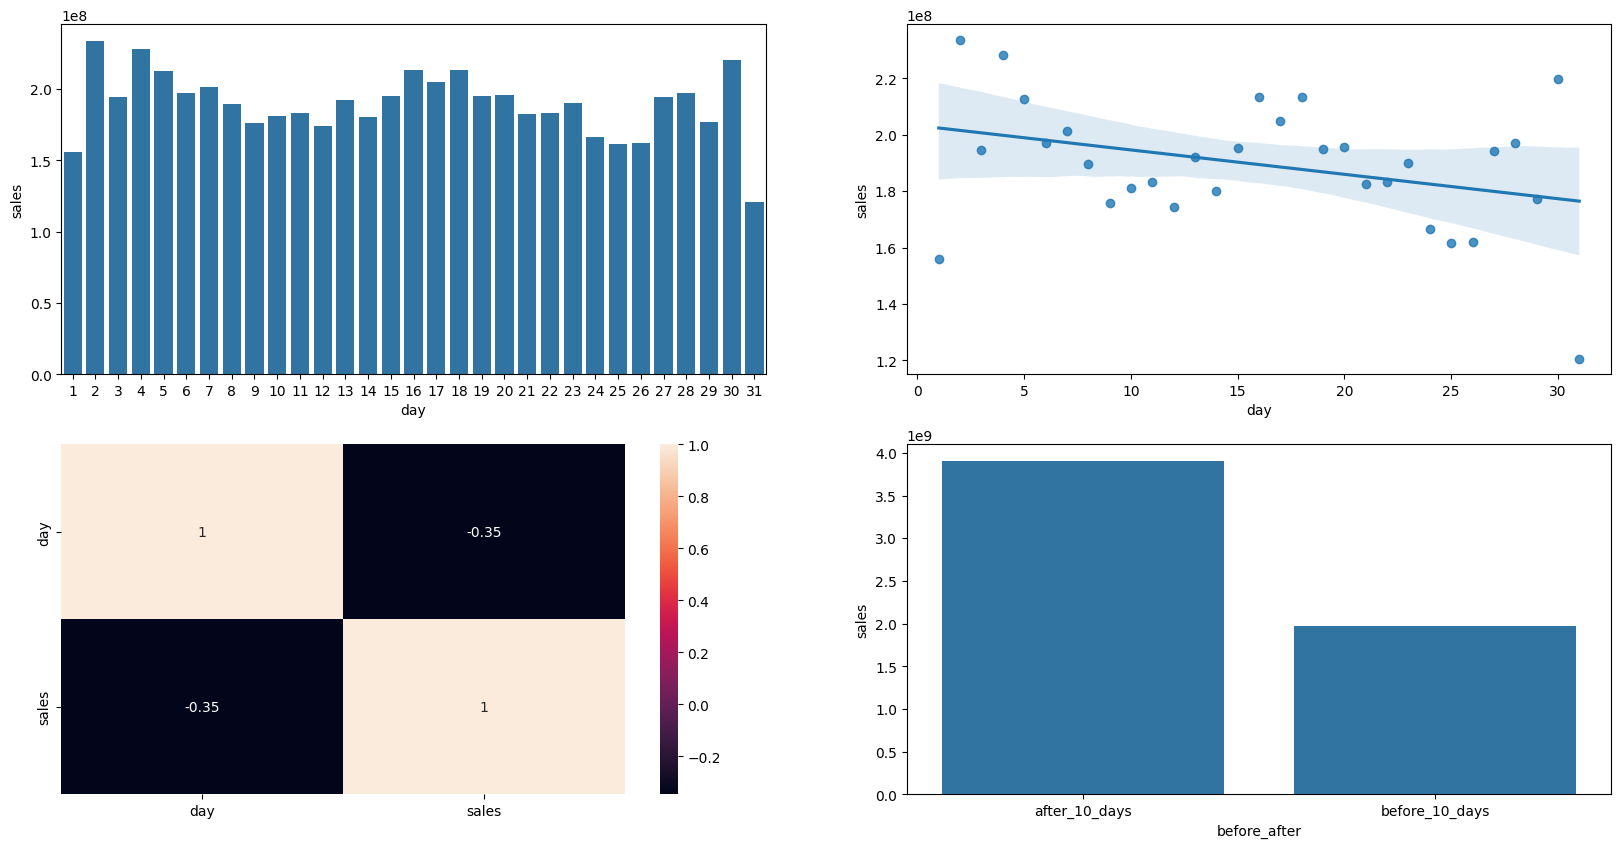

In [255]:
aux1 = df4[['day', 'sales']].groupby('day').sum().reset_index()

plt.figure(figsize=(20, 10))

plt.subplot(2,2,1)
sns.barplot(x='day', y='sales', data=aux1);
plt.subplot(2,2,2)
sns.regplot(x='day', y='sales', data=aux1);
plt.subplot(2,2,3)
sns.heatmap(aux1.corr(method='pearson'),annot = True);

aux1['before_after'] = aux1['day'].apply(lambda x: 'before_10_days' if x <= 10 else 'after_10_days')
aux2 = aux1[['before_after','sales']].groupby('before_after').sum().reset_index()
plt.subplot(2,2,4)
sns.barplot(x='before_after', y='sales', data=aux2)
plt.show()

### 4.2.11 H11 - Lojas deveriam vender menos aos finais de semana
### **Verdadeira - Lojas vendem menos aos finais de semana**

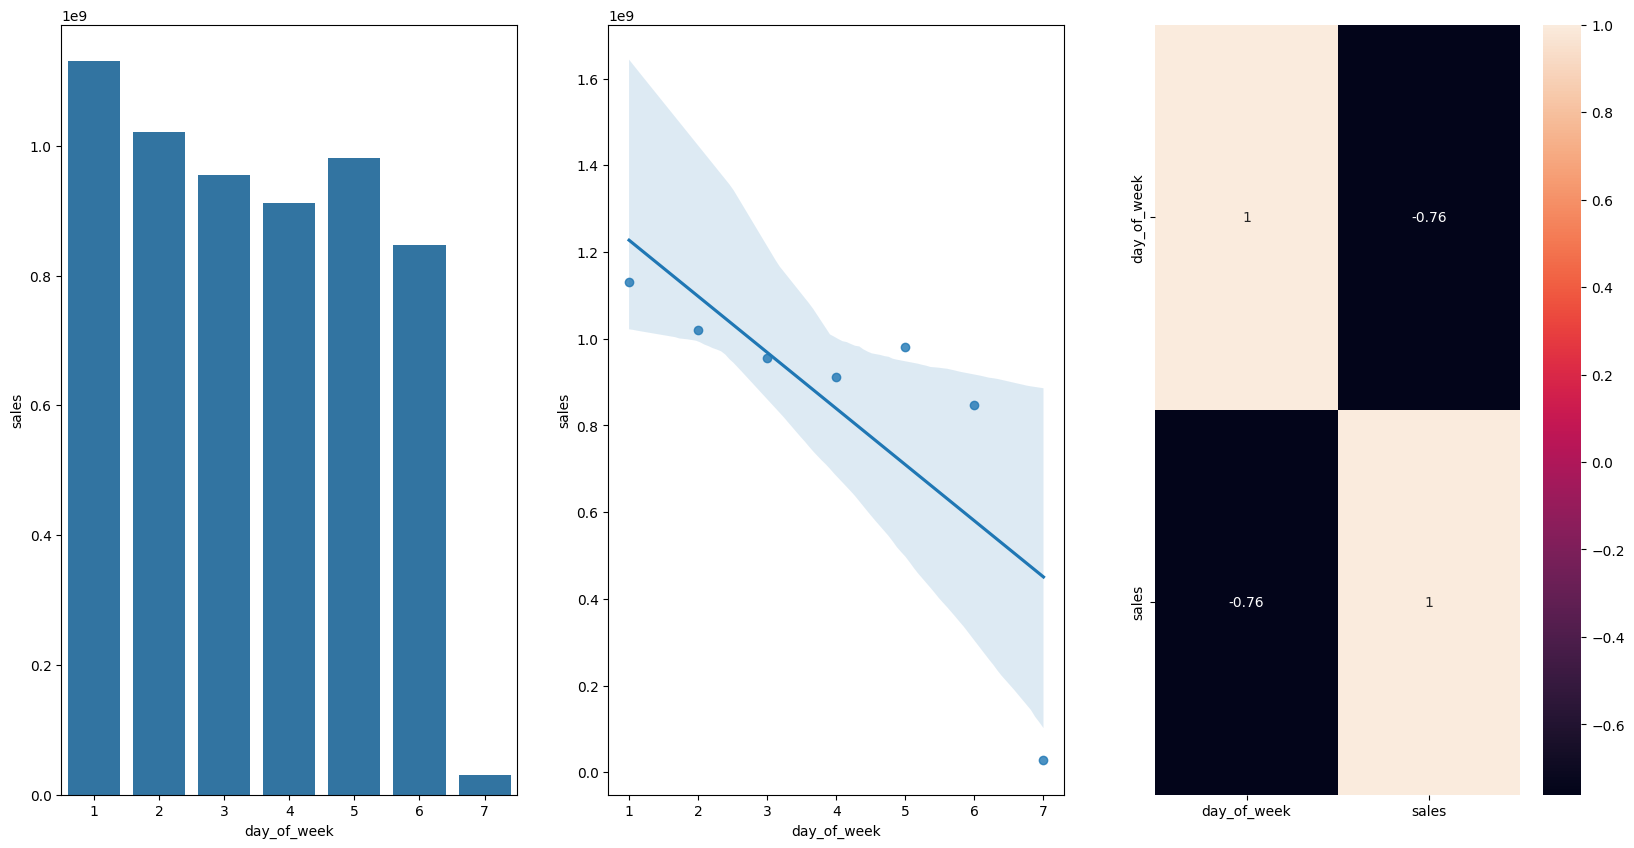

In [256]:
aux1 = df4[['day_of_week', 'sales']].groupby('day_of_week').sum().reset_index()

plt.figure(figsize=(20, 10))

plt.subplot(1,3,1)
sns.barplot(x='day_of_week', y='sales', data=aux1);
plt.subplot(1,3,2)
sns.regplot(x='day_of_week', y='sales', data=aux1);
plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'),annot = True);
plt.show()

### 4.2.12 H12 - Lojas deveriam vender menos durante os feriados escolares.  
### **Verdadeira - Com excessão das férias escolares, as lojas vendem menos durante os feriados escolares**

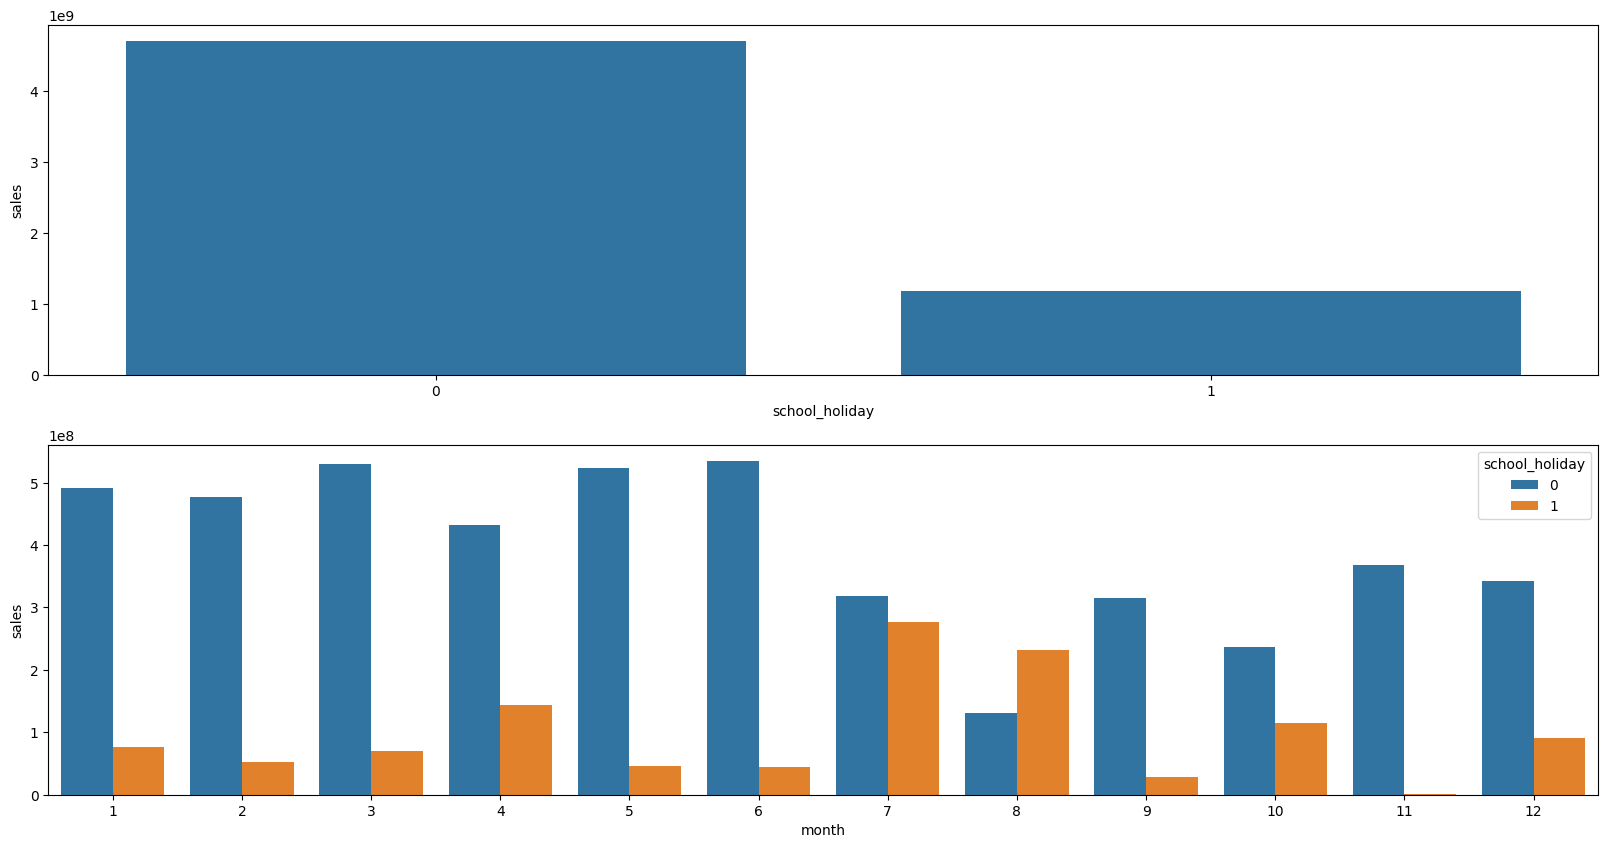

In [257]:
plt.figure(figsize=(20, 10))

plt.subplot(2,1,1)

aux1 = df4[['school_holiday', 'sales']].groupby('school_holiday').sum().reset_index()
sns.barplot(x='school_holiday',y='sales',data = aux1)

plt.subplot(2,1,2)
aux2 = df4[['month','school_holiday', 'sales']].groupby(['month','school_holiday']).sum().reset_index()
sns.barplot(x='month',y='sales',hue='school_holiday',data = aux2)

plt.show()

## 4.3 Analise Multivariada

### 4.3.1 - Numerical Attributes

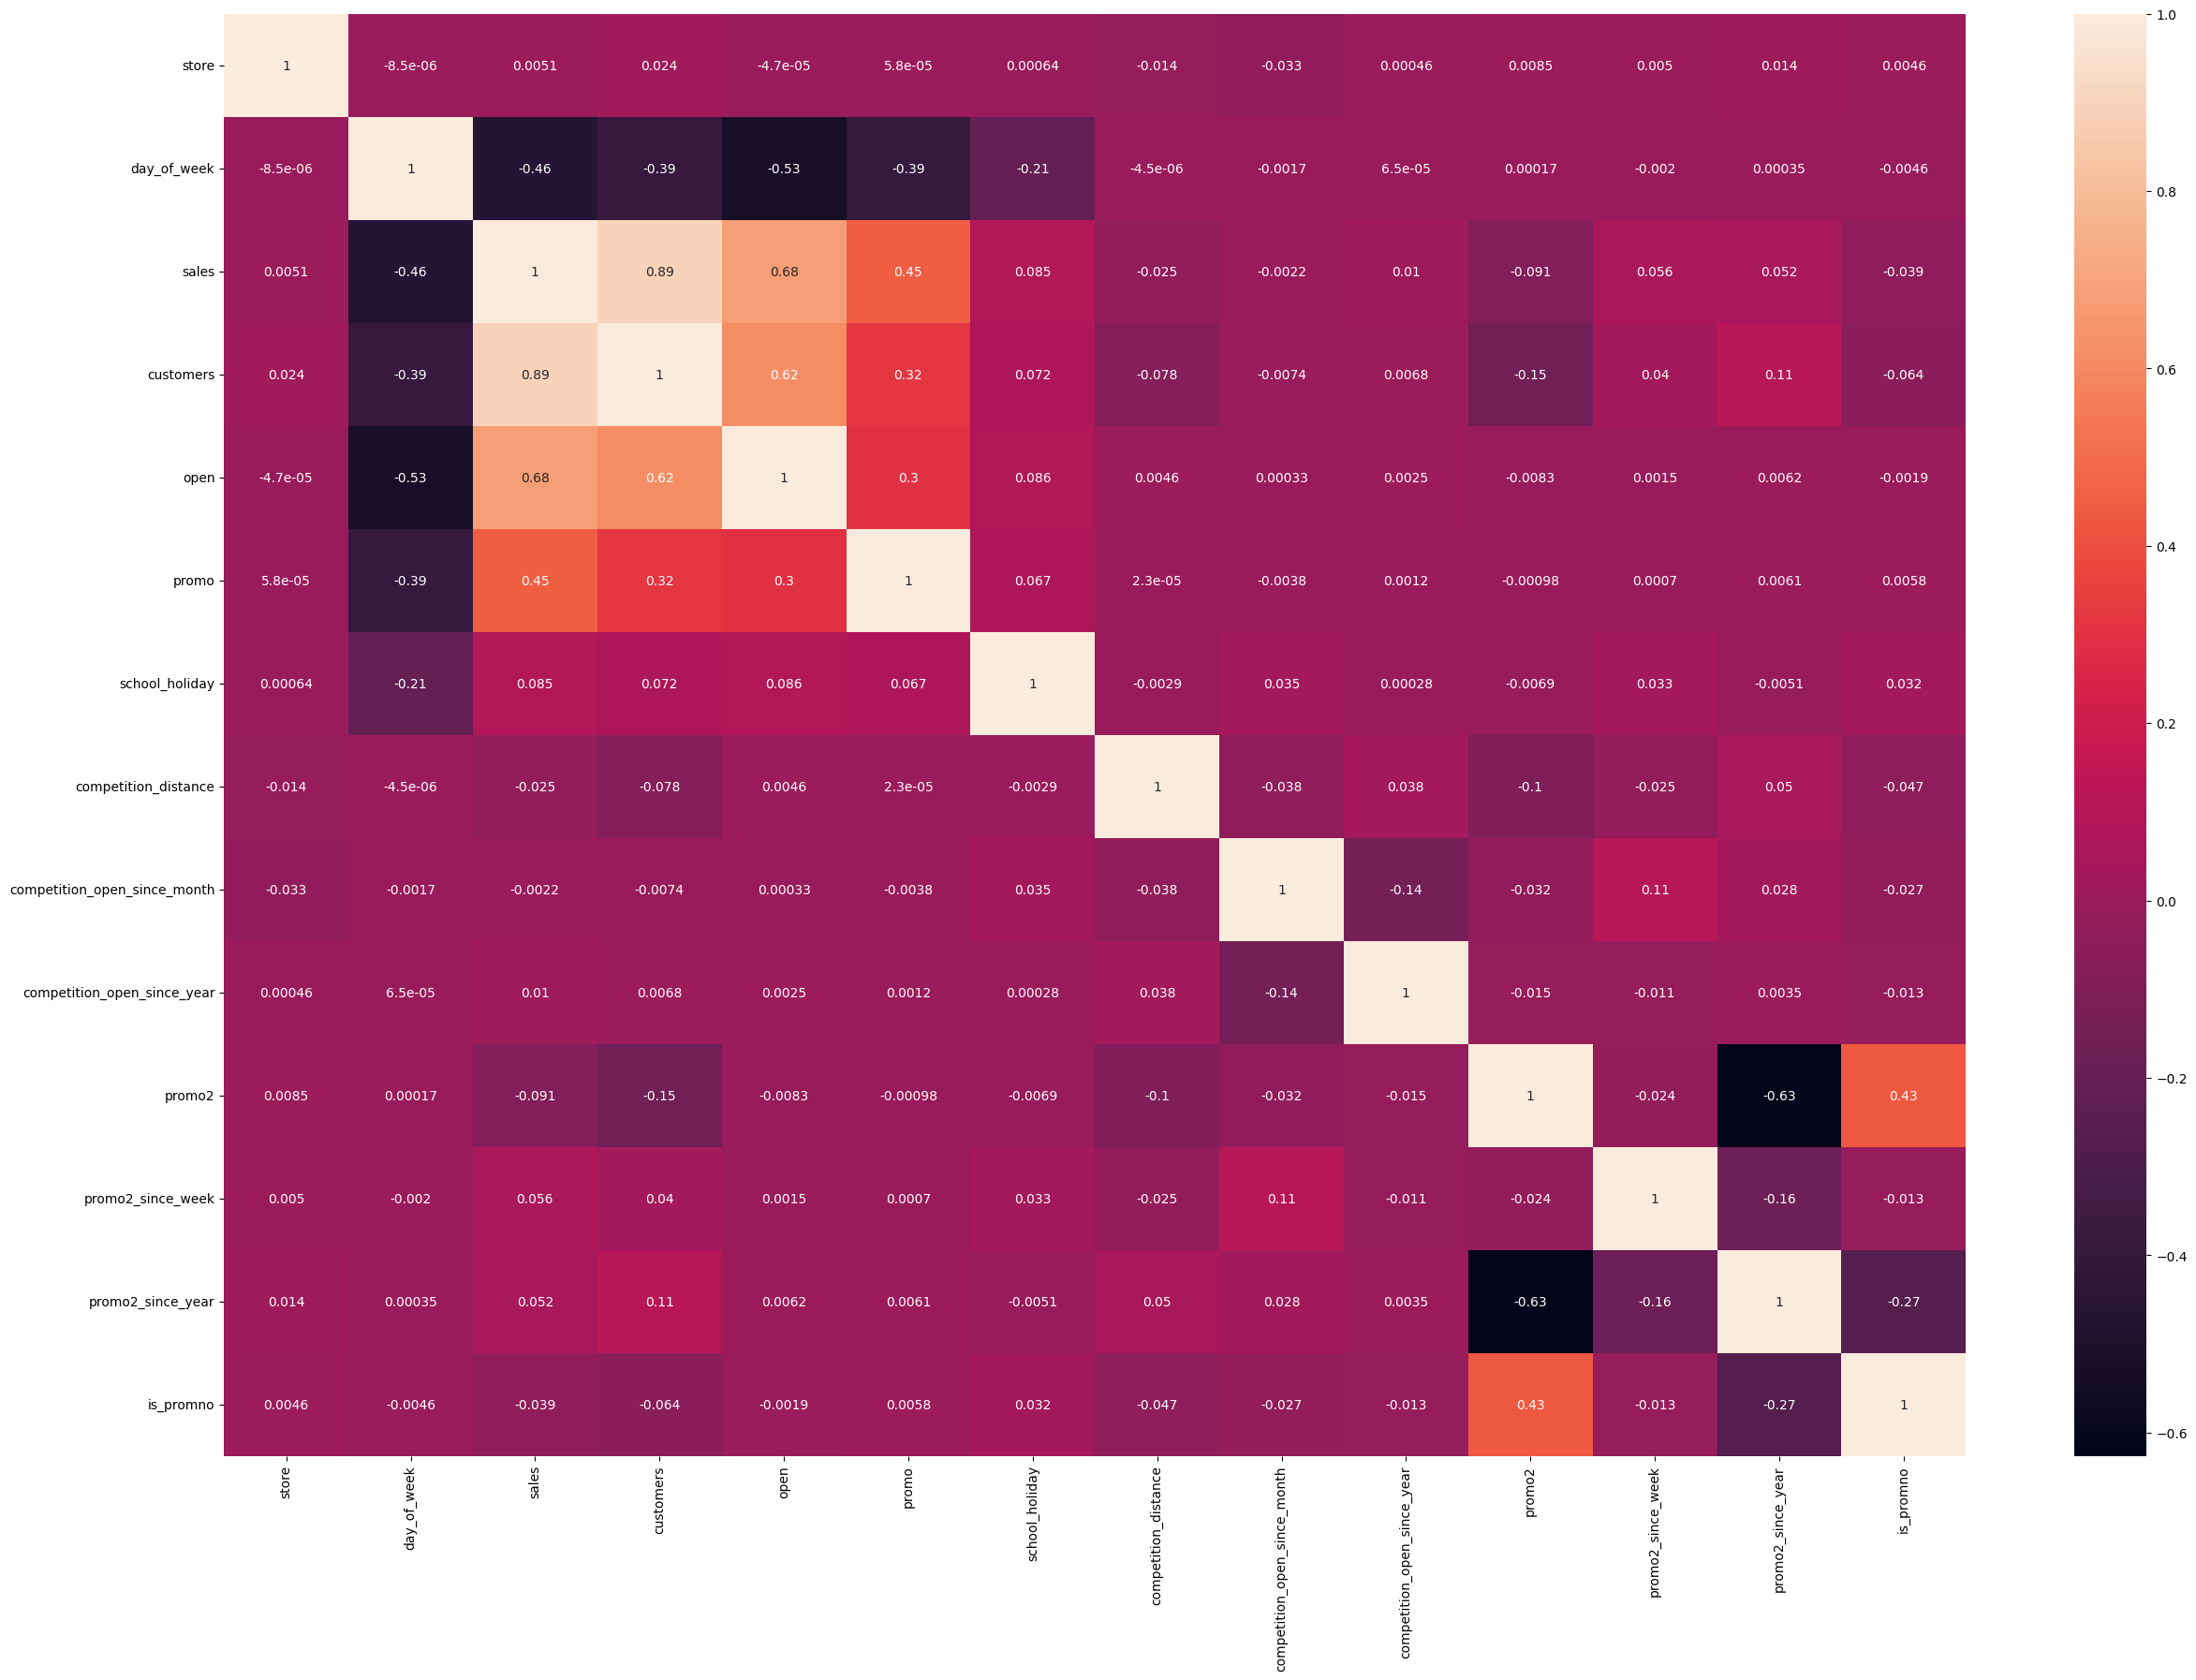

In [258]:
correlation = num_attributes.corr(method='pearson')
plt.figure(figsize=(30,20))

sns.heatmap(correlation,annot=True)
plt.show()

### 4.3.2 - Categorical Attributes

In [259]:
a= df4.select_dtypes(include = 'object')
a.head()

,state_holiday,store_type,assortment,year_week
0,regular_day,c,basic,2015-30
1,regular_day,a,basic,2015-30
2,regular_day,a,basic,2015-30
3,regular_day,c,extended,2015-30
4,regular_day,a,basic,2015-30


In [260]:
a1 = cramer_v(a['state_holiday'], a['state_holiday'])
a2 = cramer_v(a['state_holiday'], a['store_type'])
a3 = cramer_v(a['state_holiday'], a['assortment'])

a4 = cramer_v(a['store_type'], a['state_holiday'])
a5 = cramer_v(a['store_type'], a['store_type'])
a6 = cramer_v(a['store_type'], a['assortment'])

a7 = cramer_v(a['assortment'], a['state_holiday'])
a8 = cramer_v(a['assortment'], a['store_type'])
a9 = cramer_v(a['assortment'], a['assortment'])

d = pd.DataFrame({'state_holiday':[a1,a2,a3], 
              'store_type':[a4,a5,a6], 
              'assortment':[a7,a8,a9]  })
d= d.set_index(d.columns)

<Axes: >

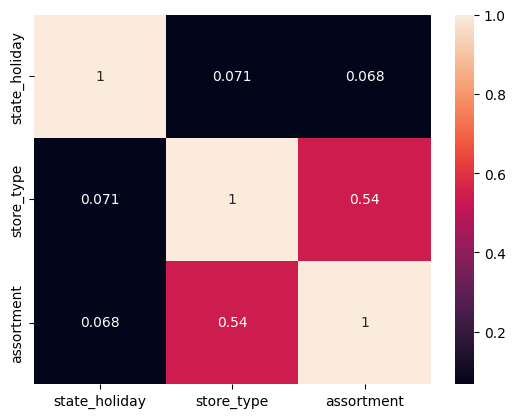

In [261]:
sns.heatmap(d,annot=True)

# 5.0 DATA PREPARATION

In [278]:
df5 = df4.copy()

## 5.1 Normalização

## 5.2 Rescalling

In [279]:
rs = RobustScaler()
mms = MinMaxScaler()

#competition_distance - Tem outliers relevantes
df5['competition_distance'] = rs.fit_transform(df5[['competition_distance']].values)

#competition_time_month - Tem outliers relevantes
df5['competition_time_month'] = rs.fit_transform(df5[['competition_time_month']].values)

#promo_time_week - Não tem outliers relevantes
df5['promo_time_week'] = mms.fit_transform(df5[['promo_time_week']].values)

#year - Não tem outliers relevantes
df5['year'] = mms.fit_transform(df5[['year']].values)

## 5.3 Transformação

### 5.3.1 Encoding

In [280]:
#state_holiday - One hot encoding
df5 = pd.get_dummies(df5,columns=['state_holiday'],prefix='state_holiday',drop_first=False,dtype=float)

#store_type - label encoding
le= LabelEncoder()
df5['store_type']=le.fit_transform(df5['store_type'])

#assortment - Ordinal encoding
assortment_dict = {'basic': 1,
                   'extra':2,
                   'extended':3}
df5['assortment'] = df5['assortment'].map(assortment_dict)

### 5.3.2 Response Variable Trnasformation 

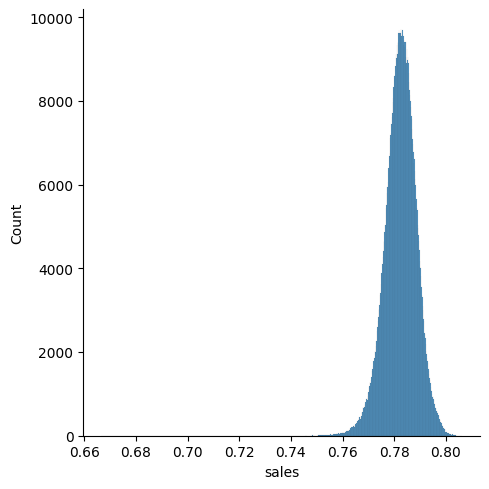

In [286]:
df5['sales'] = np.log1p(df5['sales'])
sns.displot(df5['sales']);


### 5.3.3 Nature Transformation

In [289]:
#month
df5['month_sin']=df5['month'].apply(lambda x: np.sin(x*(2.*np.pi/12)))
df5['month_cos']=df5['month'].apply(lambda x: np.cos(x*(2.*np.pi/12)))
#day
df5['day_sin']=df5['day'].apply(lambda x: np.sin(x*(2.*np.pi/30)))
df5['day_cos']=df5['day'].apply(lambda x: np.cos(x*(2.*np.pi/30)))
#week_of_year
df5['week_sin']=df5['week_of_year'].apply(lambda x: np.sin(x*(2.*np.pi/52)))
df5['week_cos']=df5['week_of_year'].apply(lambda x: np.cos(x*(2.*np.pi/52)))
#day_of_week
df5['dweek_sin']=df5['day_of_week'].apply(lambda x: np.sin(x*(2.*np.pi/7)))
df5['dweek_cos']=df5['day_of_week'].apply(lambda x: np.cos(x*(2.*np.pi/7)))